# R1 - RSAS - REPRODUCTION

In [1]:
import sentence_transformers
import pandas as pd
import numpy as np
from sklearn.preprocessing import normalize

In [8]:
#load model
model = sentence_transformers.SentenceTransformer('sentence-transformers/all-mpnet-base-v2')
def extract_embeddings(responses):
    """Transform responses into embeddings using a given embedding model."""
    embeddings = model.encode(responses, convert_to_tensor=True)  # Procesar lista, no string único
    embeddings = np.atleast_2d(embeddings.cpu().numpy())  # Asegurar que sea 2D
    return embeddings

def normalize_embeddings(embeddings):
    return normalize(embeddings, axis=1)

def calculate_gramian(embeddings):
    """Calculate the Gramian matrix using dot product."""
    #gramian = np.dot(embeddings, embeddings.T)
    gramian = np.matmul(embeddings, embeddings.T)
    return gramian

In [3]:
%cd /mnt/f/robusto/vqa_analysis

/mnt/f/robusto/vqa_analysis


In [189]:
df_r1 = pd.read_csv("data/r1_cleaned.csv", keep_default_na=False)

#remove all rows with [Empty] from the answers
df_r1 = df_r1[df_r1["ANSWER"] != "[Empty]"].reset_index(drop=True)
df_r1.info()

<class 'pandas.DataFrame'>
RangeIndex: 6294 entries, 0 to 6293
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   AGENT         6294 non-null   str  
 1   VIDEO         6294 non-null   str  
 2   QUESTION_NUM  6294 non-null   int64
 3   QUESTION      6294 non-null   str  
 4   ANSWER        6294 non-null   str  
 5   REPETITION    6294 non-null   int64
 6   BLOCK         6294 non-null   int64
dtypes: int64(3), str(4)
memory usage: 1.1 MB


In [190]:
#select all the human responses
def is_human_agent(agent):
    return "Humano" in agent

sort_cols = ["VIDEO", "QUESTION_NUM"]  # <- cambia QUESTION_ID por tu columna real
mask_h = df_r1["AGENT"].apply(is_human_agent)
df_r1_humans = df_r1[mask_h]
df_r1_vlms = df_r1[~mask_h]
r = df_r1_humans[df_r1_humans["AGENT"] == "Humano2"]
r

,AGENT,VIDEO,QUESTION_NUM,QUESTION,ANSWER,REPETITION,BLOCK
3282,Humano2,Robusto 1_201,1,Q1: What driving action is taking place?,Going forward and breaking,1,1
3283,Humano2,Robusto 1_201,2,Q2: Is there any interaction with other vehicles?,Yes,1,1
3284,Humano2,Robusto 1_201,3,Q3: What is the weather and road condition?,Good,1,1
3285,Humano2,Robusto 1_201,4,Q4: Is there any traffic light present?,No,1,1
3286,Humano2,Robusto 1_201,5,Q5: What is the traffic flow in the scene?,Heavy,1,1
...,...,...,...,...,...,...,...
3382,Humano2,Robusto 1_207,11,Q11: What would have had to happen in this vid...,not breaking,1,3
3383,Humano2,Robusto 1_207,12,Q12: What would have had to happen in this vid...,idk,1,3
3384,Humano2,Robusto 1_207,13,Q13: What would have happened in the scene if ...,hitting pedestrians,1,3
3385,Humano2,Robusto 1_207,14,Q14: What would be the next action to perform ...,idk,1,3


## PROCESSING HUMANS

In [191]:
embeds_humans_block = {}
humans = df_r1_humans["AGENT"].unique()
model.encode("", convert_to_tensor=True)  # Warm up the model
for human in humans:
    print(f"Processing responses for {human}...")
    local_df =  local_df = (
        df_r1_humans[df_r1_humans["AGENT"] == human]
        .sort_values(by=["VIDEO","QUESTION_NUM"])
        .reset_index(drop=True)
    )
    
    blocks = local_df["BLOCK"].unique()
    responses = local_df["ANSWER"].astype(str).tolist()
    
    if "None" in responses:
        print(f"Warning: Found 'None' in responses for {human}. This SHOULD OCURR.")
    
    print(f"Extracting embeddings for {len(responses)} responses...")
    embeddings = extract_embeddings(responses)
    print(f"Embeddings shape for {human}: {embeddings.shape}")
    
    normalized_embeddings = normalize_embeddings(embeddings)
    for block in blocks:
        block_indices = local_df[local_df["BLOCK"] == block].index
        embeds_humans_block[(human, block)] = normalized_embeddings[block_indices]


Processing responses for Humano1...
Extracting embeddings for 105 responses...
Embeddings shape for Humano1: (105, 768)
Processing responses for Humano2...
Extracting embeddings for 105 responses...
Embeddings shape for Humano2: (105, 768)
Processing responses for Humano3...
Extracting embeddings for 105 responses...
Embeddings shape for Humano3: (105, 768)
Processing responses for Humano4...
Extracting embeddings for 105 responses...
Embeddings shape for Humano4: (105, 768)
Processing responses for Humano5...
Extracting embeddings for 105 responses...
Embeddings shape for Humano5: (105, 768)
Processing responses for Humano6...
Extracting embeddings for 105 responses...
Embeddings shape for Humano6: (105, 768)
Processing responses for Humano7...
Extracting embeddings for 105 responses...
Embeddings shape for Humano7: (105, 768)
Processing responses for Humano8...
Extracting embeddings for 105 responses...
Embeddings shape for Humano8: (105, 768)
Processing responses for Humano9...
Extr

In [192]:
local_df

,AGENT,VIDEO,QUESTION_NUM,QUESTION,ANSWER,REPETITION,BLOCK
0,Humano9,Robusto 1_201,1,Q1: What driving action is taking place?,The car is carefully turning left at a congest...,1,1
1,Humano9,Robusto 1_201,2,Q2: Is there any interaction with other vehicles?,It seems like the decisions taken by the drive...,1,1
2,Humano9,Robusto 1_201,3,Q3: What is the weather and road condition?,"The weather is slightly rainy, and the road ap...",1,1
3,Humano9,Robusto 1_201,4,Q4: Is there any traffic light present?,there is no visible traffic light present.,1,1
4,Humano9,Robusto 1_201,5,Q5: What is the traffic flow in the scene?,"It appears to be congested, with cars coming f...",1,1
...,...,...,...,...,...,...,...
100,Humano9,Robusto 1_207,11,Q11: What would have had to happen in this vid...,The driver would have had to speed up faster,1,3
101,Humano9,Robusto 1_207,12,Q12: What would have had to happen in this vid...,A pedestrian would have had to cross at the mo...,1,3
102,Humano9,Robusto 1_207,13,Q13: What would have happened in the scene if ...,I would have run over some pedestrians.,1,3
103,Humano9,Robusto 1_207,14,Q14: What would be the next action to perform ...,"instead of turning right, the ambulance should...",1,3


## PROCESSING VLMS

In [193]:
embeds_vlms_block = {}
vlms = df_r1_vlms["AGENT"].unique()

dummy_embedding = model.encode([""], convert_to_tensor=True)
embedding_dim = dummy_embedding.shape[-1]  # Obtiene la dimensión del embedding

for vlm in vlms:
    
    #here is different from humans since there exists the repetition label, we have to compute embeds then get the "mean"
    print(f"Processing responses for {vlm}...")
    local_df =  local_df = (
        df_r1_vlms[df_r1_vlms["AGENT"] == vlm]
        .sort_values(by=["VIDEO","QUESTION_NUM"])
        .reset_index(drop=True)
    )
    
    # #use repetition 1 only 
    # local_df_rep1 = local_df[local_df["REPETITION"] == 1].reset_index(drop=True)
    
    # blocks = local_df_rep1["BLOCK"].unique()
    # responses = local_df_rep1["ANSWER"].astype(str).tolist()
    
    # if "None" in responses:
    #     print(f"Warning: Found 'None' in responses for {vlm}. This SHOULD OCURR.")
    
    # print(f"Extracting embeddings for {len(responses)} responses...")
    # embeddings = extract_embeddings(responses)
    # print(f"Embeddings shape for {vlm}: {embeddings.shape}")
    
    # normalized_embeddings = normalize_embeddings(embeddings)
    # for block in blocks:
    #     block_indices = local_df_rep1[local_df_rep1["BLOCK"] == block].index
    #     embeds_vlms_block[(vlm, block)] = normalized_embeddings[block_indices]
    

    mean_embeddings = []
    #process each question and get the mean of the responses for the answer of each question group by question num and video
    groups = local_df.groupby(["VIDEO", "QUESTION_NUM"],sort=False)
    for _, group in groups:
        responses = group["ANSWER"].astype(str).tolist()
        if len(responses) == 0:
            avg_embedding = np.zeros(embedding_dim)  # O cualquier valor predeterminado
        else:
            embeds = extract_embeddings(responses)
            norm_embeds = normalize_embeddings(embeds)
            avg_embedding = np.mean(embeds, axis=0)
            #normalize the average embedding
            avg_embedding = avg_embedding / np.linalg.norm(avg_embedding)
        mean_embeddings.append(avg_embedding)
        
    mean_embeddings = np.array(mean_embeddings)
    local_df_final = local_df.drop_duplicates(subset=["VIDEO", "QUESTION_NUM"], keep="first").copy().reset_index(drop=True)
    blocks = local_df_final["BLOCK"].unique()
    for block in blocks:
        block_indices = local_df_final[local_df_final["BLOCK"] == block].index
        #how many responses are in this block?
        print(f"Block {block} has {len(block_indices)} responses for {vlm}.")
        embeds_vlms_block[(vlm, block)] = mean_embeddings[block_indices]

Processing responses for cogvlm2...
Block 1 has 35 responses for cogvlm2.
Block 2 has 35 responses for cogvlm2.
Block 3 has 35 responses for cogvlm2.
Processing responses for deepseek_v2...
Block 1 has 35 responses for deepseek_v2.
Block 2 has 35 responses for deepseek_v2.
Block 3 has 35 responses for deepseek_v2.
Processing responses for gemini-2.0...
Block 1 has 35 responses for gemini-2.0.
Block 2 has 35 responses for gemini-2.0.
Block 3 has 35 responses for gemini-2.0.
Processing responses for Llama-3.2...
Block 1 has 35 responses for Llama-3.2.
Block 2 has 35 responses for Llama-3.2.
Block 3 has 35 responses for Llama-3.2.
Processing responses for pixtral...
Block 1 has 35 responses for pixtral.
Block 2 has 35 responses for pixtral.
Block 3 has 35 responses for pixtral.
Processing responses for qwen2...
Block 1 has 35 responses for qwen2.
Block 2 has 35 responses for qwen2.
Block 3 has 35 responses for qwen2.


## RSA ANALYSIS

In [194]:
ORDER_AGENTS = [
    'cogvlm2',     # El camaleón de visual help
    'qwen2',       # El logo geométrico de Alibaba
    'gemini-2.0',  # La G de Google
    'pixtral',     # El logo de Mistral (la H estilizada)
    'Llama-3.2',   # El logo de Meta
    'deepseek_v2'  # La ballena
]

#JOIN THE HUMANS
agents = ORDER_AGENTS + [f"Humano{i}" for i in range(1, 10)]

embeds_by_block = {**embeds_humans_block, **embeds_vlms_block}
embeds_by_block = dict(sorted(embeds_by_block.items(), key=lambda x: agents.index(x[0][0]) if x[0][0] in agents else len(agents)))

In [195]:
from scipy.stats import pearsonr

#compute gramians for each block
blocks = df_r1["BLOCK"].unique()
gramians = {}
rsas = {}

#first compute gramian
for key in embeds_by_block:
    human, block = key
    embeddings = embeds_by_block[key]
    gramian = calculate_gramian(embeddings)
    gramians[key] = gramian

#then compute rsa for each pair of agents for each block
for b in blocks:
    rsa_matrix = np.zeros((len(agents), len(agents)))
    for i, agent_i in enumerate(agents):
        for j, agent_j in enumerate(agents):
            if i <= j:  # Evitar duplicados y auto-comparaciones
                key_i = (agent_i, b)
                key_j = (agent_j, b)

                gramian_i = gramians[key_i]
                gramian_j = gramians[key_j]
                
                upper1 = gramian_i[np.triu_indices_from(gramian_i, k=1)]
                upper2 = gramian_j[np.triu_indices_from(gramian_j, k=1)]

                correlation, _ = pearsonr(upper1, upper2)
                rsa_matrix[i, j] = correlation
                rsa_matrix[j, i] = correlation
                rsas[b] = rsa_matrix                

Saving RSA plot with title: RSA - Robusto 1 as rsa_output_rsa_-_robusto_1.png


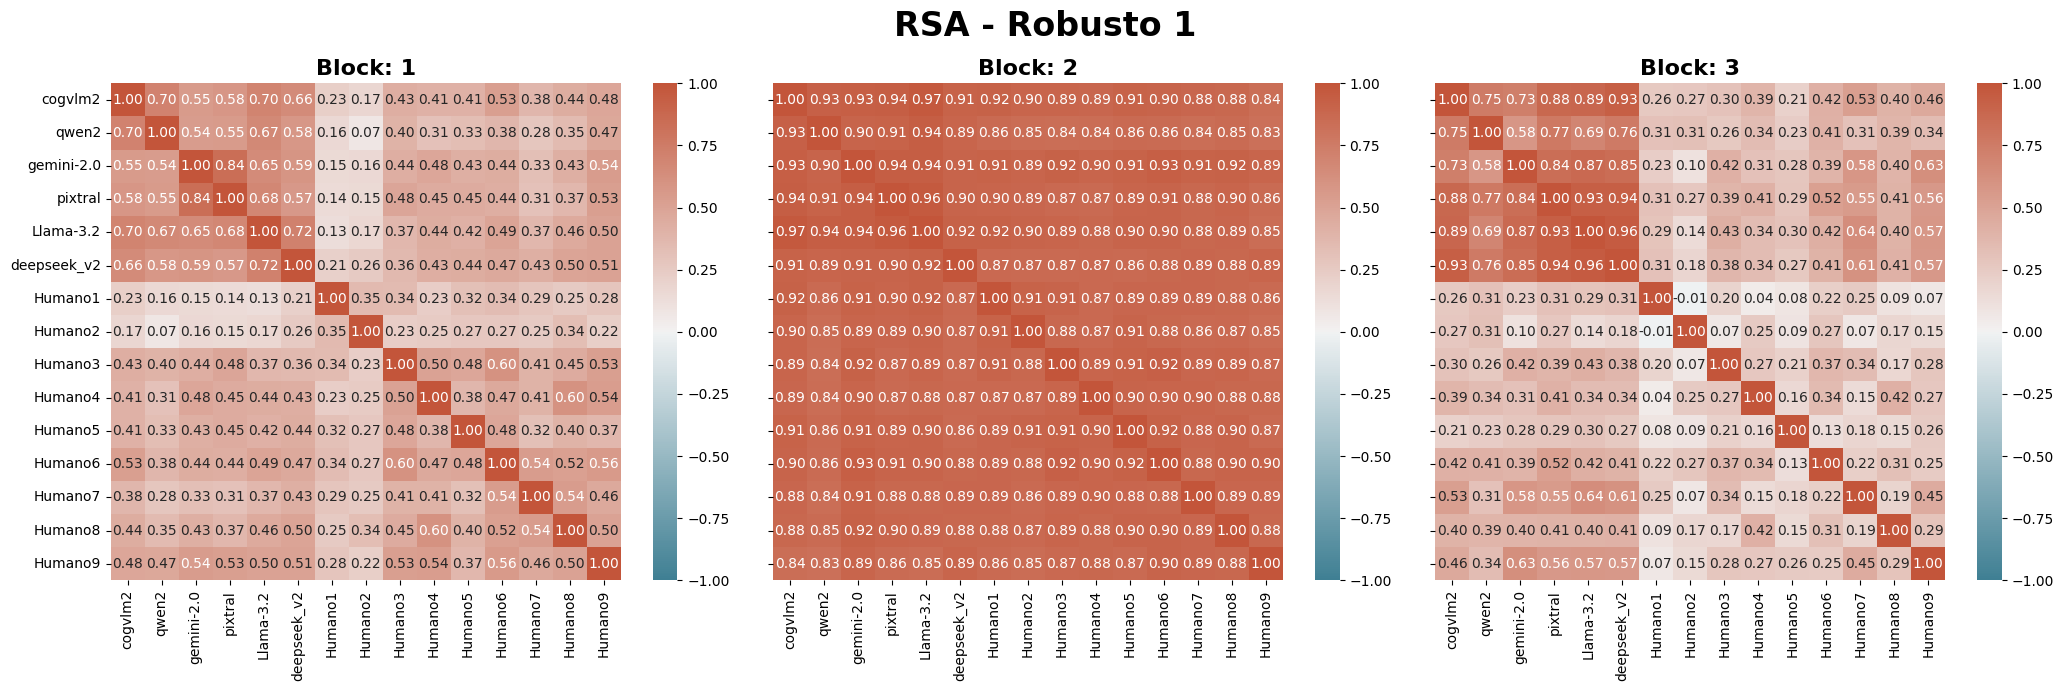

In [196]:
import matplotlib.pyplot as plt
import seaborn as sns
nrows = 1
ncols = len(blocks)
title = "RSA - Robusto 1"

fig, ax = plt.subplots(nrows, ncols, figsize=(7 * ncols, 7 * nrows), sharex=True, sharey=True)
ax = np.atleast_1d(ax).ravel()
c = sns.diverging_palette(220, 20, as_cmap=True)

for block in sorted(df_r1_humans["BLOCK"].astype(int).unique()):
    c_ax = ax[block - 1]
    rsa_matrix = rsas[np.int64(block)]
    sns.heatmap(np.round(rsa_matrix,3), annot=True, xticklabels=agents, yticklabels=agents, cmap=c, ax=c_ax, vmin=-1, vmax=1, center=0, fmt=".2f")
    c_ax.set_title(f"Block: {block}", fontsize=16, weight="bold")
    
fig.suptitle(title, fontsize=24, weight="bold")
out_name = title.replace(" ", "_").replace(":","-").lower()
print(f"Saving RSA plot with title: {title} as rsa_output_{out_name}.png")
fig.tight_layout()
fig.savefig(f"./rsa_output_{out_name}.png", dpi=300)

In [109]:
r = df_r1_humans[df_r1_humans["AGENT"] == humans[2]]
r

,AGENT,VIDEO,QUESTION_NUM,QUESTION,ANSWER,REPETITION,BLOCK
3465,Humano3,Robusto 1_201,1,Q1: What driving action is taking place?,Merging into a busy intersection,1,1
3466,Humano3,Robusto 1_201,2,Q2: Is there any interaction with other vehicles?,Breaking because of possible contact,1,1
3467,Humano3,Robusto 1_201,3,Q3: What is the weather and road condition?,rainy weather and wet road,1,1
3468,Humano3,Robusto 1_201,4,Q4: Is there any traffic light present?,none visible,1,1
3469,Humano3,Robusto 1_201,5,Q5: What is the traffic flow in the scene?,heavy flow,1,1
...,...,...,...,...,...,...,...
3565,Humano3,Robusto 1_207,11,Q11: What would have had to happen in this vid...,the driver would have had to not see the pedes...,1,3
3566,Humano3,Robusto 1_207,12,Q12: What would have had to happen in this vid...,some cars would have had to disobey the traffi...,1,3
3567,Humano3,Robusto 1_207,13,Q13: What would have happened in the scene if ...,a pedestrian would have been ran over,1,3
3568,Humano3,Robusto 1_207,14,Q14: What would be the next action to perform ...,it is not possible to do a u turn in an ambula...,1,3


In [ ]:
!nvidia-smi

def free_gpu_memory():
    import torch
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        print("GPU memory freed.")
    else:
        print("No GPU available.")
free_gpu_memory()

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


Wed Feb 25 12:33:14 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 575.64.04              Driver Version: 577.00         CUDA Version: 12.9     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce GTX 1650 ...    On  |   00000000:06:00.0  On |                  N/A |
| 58%   46C    P2             24W /  100W |    2932MiB /   4096MiB |      1%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----